# Inovalab — Modelos sobre habilitaciones de la CABA

**Notebook 02 — regresión (volumen) y clasificación (comuna)**

Usa el CSV ya limpio y georreferenciado por el notebook 01
(`data/processed/habilitaciones_caba_clean.csv`). La lógica reutilizable vive en
`src/modelado.py`; acá se entrena, evalúa y se presentan los resultados.

| Problema | Target | Métrica |
|----------|--------|---------|
| Regresión | habilitaciones por (comuna, año) | R² · RMSE · MAE |
| Clasificación | comuna desde el perfil de actividad | accuracy · F1 (macro/weighted) |


In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_loader import load_processed
from src.modelado import agregado_comuna_anio, comparar_clasificadores, features_comuna

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)

df = load_processed()
print("Dataset:", df.shape)

Dataset: (216991, 20)


## 1. Regresión: volumen por (comuna, año)

Target = cantidad de registros por comuna y año; features = año + comuna.
Se reportan dos splits:

* **aleatorio**: mide cuánta varianza del volumen explican (comuna, año);
* **temporal** (entrena ≤ 2023, prueba 2024-2026): mide si sirve para
  *pronosticar*. Es importante ver el contraste: `anio` es el **año del archivo
  fuente**, no una serie temporal regular, así que extrapolar puede fallar.


In [2]:
agg = agregado_comuna_anio(df)
print("Observaciones (comuna, año):", len(agg))
display(agg.pivot_table(index="comuna", columns="anio", values="habilitaciones", fill_value=0))

Observaciones (comuna, año): 107


anio,2015,2019,2020,2021,2023,2024,2025,2026
comuna,,,,,,,,
1,15150.0,2265.0,669.0,1883.0,234.0,338.0,5324.0,1.0
2,6922.0,1033.0,229.0,397.0,71.0,150.0,1994.0,0.0
3,22346.0,2269.0,430.0,702.0,159.0,256.0,4239.0,0.0
4,6077.0,975.0,201.0,452.0,74.0,146.0,1138.0,0.0
5,6927.0,898.0,217.0,386.0,88.0,143.0,459.0,1.0
6,5501.0,848.0,200.0,325.0,64.0,110.0,559.0,0.0
7,11128.0,1362.0,316.0,607.0,98.0,193.0,908.0,0.0
8,2600.0,325.0,98.0,142.0,29.0,62.0,479.0,0.0
9,6767.0,1035.0,229.0,340.0,76.0,131.0,1363.0,0.0


Split aleatorio:
  R² prueba:  0.414
  RMSE:         2756.0
  MAE:          2204.2
Split temporal (extrapolar a 2024-2026):
  R² prueba:  -13.77  -> `anio` es el año del archivo, no una serie regular


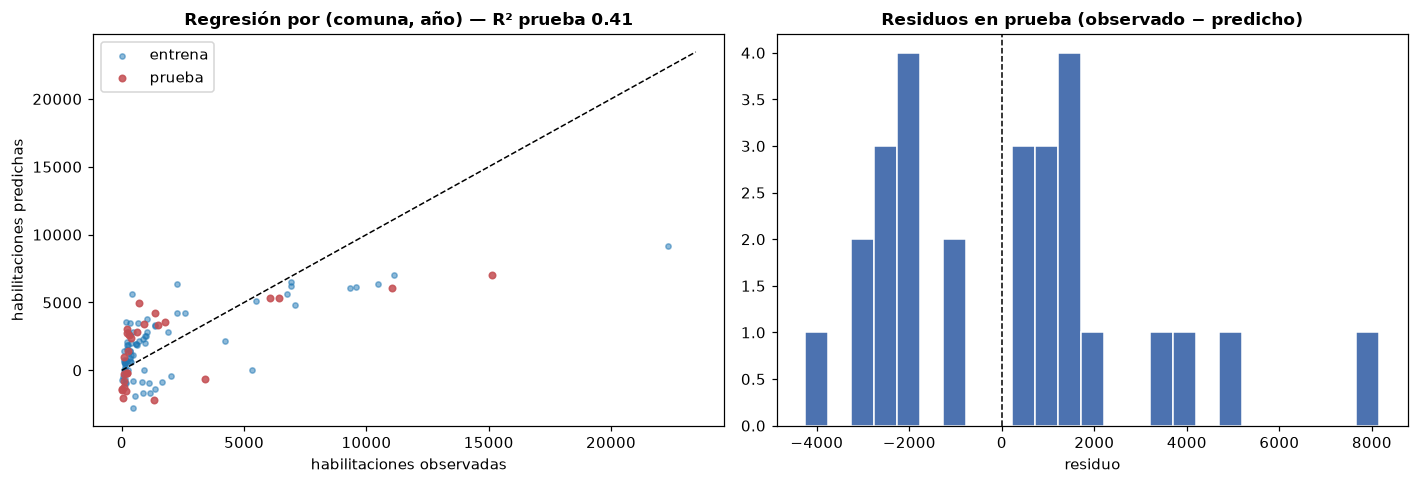

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = pd.get_dummies(agg[["anio", "comuna"]], columns=["comuna"], drop_first=True).astype(float)
y = agg["habilitaciones"].astype(float)

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.25, random_state=42)
modelo = LinearRegression().fit(X_ent, y_ent)
pred = modelo.predict(X_pru)

print("Split aleatorio:")
print(f"  R² prueba:  {r2_score(y_pru, pred):.3f}")
print(f"  RMSE:       {np.sqrt(mean_squared_error(y_pru, pred)):>8.1f}")
print(f"  MAE:        {mean_absolute_error(y_pru, pred):>8.1f}")

futuro = (agg["anio"] >= 2024).to_numpy()
modelo_t = LinearRegression().fit(X[~futuro], y[~futuro])
print("Split temporal (extrapolar a 2024-2026):")
print(f"  R² prueba:  {r2_score(y[futuro], modelo_t.predict(X[futuro])):.2f}  "
      "-> `anio` es el año del archivo, no una serie regular")

fig, eje = plt.subplots(1, 2, figsize=(13, 4.5))
eje[0].scatter(y_ent, modelo.predict(X_ent), s=12, alpha=0.5, label="entrena")
eje[0].scatter(y_pru, pred, s=18, alpha=0.85, color="#C44E52", label="prueba")
lim = [0, max(y.max(), pred.max()) * 1.05]
eje[0].plot(lim, lim, "k--", lw=1)
eje[0].set_xlabel("habilitaciones observadas")
eje[0].set_ylabel("habilitaciones predichas")
eje[0].set_title(f"Regresión por (comuna, año) — R² prueba {r2_score(y_pru, pred):.2f}")
eje[0].legend()

residuos = y_pru - pred
eje[1].hist(residuos, bins=25, color="#4C72B0", edgecolor="white")
eje[1].axvline(0, color="black", ls="--", lw=1)
eje[1].set_title("Residuos en prueba (observado − predicho)")
eje[1].set_xlabel("residuo")
fig.tight_layout()
plt.show()

## 2. Clasificación: predecir la comuna

¿Cuánto aporta el **perfil de actividad** para ubicar un local? Features:
superficie (log), año, tipo de trámite y rubro (top 10 + otros).

No se usan `seccion`, `manzana` ni `calles` a propósito: son el mapeo
determinístico que ya resuelve `src/geografia.py` (sería fuga de información).
El **baseline** es predecir siempre la comuna más frecuente.


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

X, y = features_comuna(df)
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_entrena):,} · Prueba: {len(X_prueba):,} · clases: {y.nunique()}")

modelos = {
    "Dummy (más frecuente)": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": Pipeline(
        [("escala", StandardScaler()), ("logit", LogisticRegression(max_iter=5000))]
    ),
    "Árbol (prof. 6)": DecisionTreeClassifier(max_depth=6, random_state=42),
    "KNN (k=25, escalado)": Pipeline(
        [("escala", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=25))]
    ),
}
tabla = comparar_clasificadores(modelos, X_entrena, y_entrena, X_prueba, y_prueba)
print("\nAccuracy y F1 por modelo:")
display(tabla.round(3))

Entrenamiento: 149,447 · Prueba: 49,816 · clases: 15



Accuracy y F1 por modelo:


,accuracy,f1_macro,f1_weighted
modelo,,,
Regresión logística,0.177,0.043,0.084
Árbol (prof. 6),0.176,0.043,0.083
Dummy (más frecuente),0.153,0.018,0.040
"KNN (k=25, escalado)",0.140,0.061,0.091


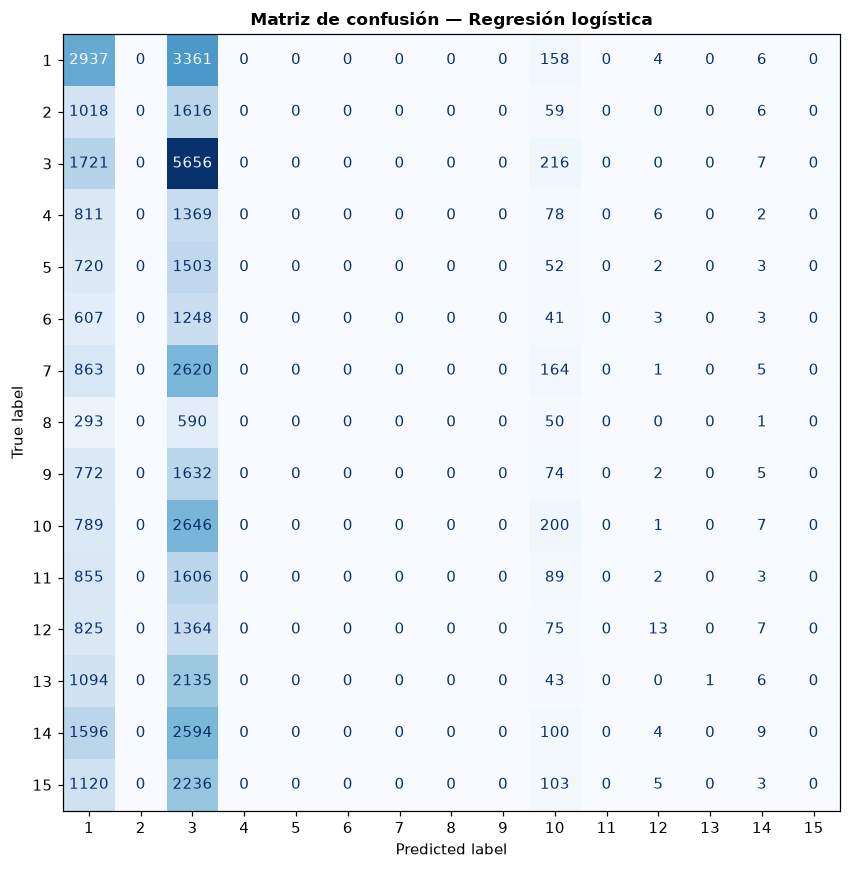

Reporte por clase — Regresión logística:
              precision    recall  f1-score   support

           1       0.18      0.45      0.26      6466
           2       0.00      0.00      0.00      2699
           3       0.18      0.74      0.28      7600
           4       0.00      0.00      0.00      2266
           5       0.00      0.00      0.00      2280
           6       0.00      0.00      0.00      1902
           7       0.00      0.00      0.00      3653
           8       0.00      0.00      0.00       934
           9       0.00      0.00      0.00      2485
          10       0.13      0.05      0.08      3643
          11       0.00      0.00      0.00      2555
          12       0.30      0.01      0.01      2284
          13       1.00      0.00      0.00      3279
          14       0.12      0.00      0.00      4303
          15       0.00      0.00      0.00      3467

    accuracy                           0.18     49816
   macro avg       0.13      0.08      

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

mejor_nombre = tabla.index[0]
mejor = modelos[mejor_nombre].fit(X_entrena, y_entrena)
pred = mejor.predict(X_prueba)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_prueba, pred, ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de confusión — {mejor_nombre}")
fig.tight_layout()
plt.show()

print(f"Reporte por clase — {mejor_nombre}:")
print(classification_report(y_prueba, pred, zero_division=0))

## 3. Conclusiones

* **Regresión**: con split aleatorio, (comuna, año) explican ~0.41 del
  volumen (el año marca el salto de los exports y la comuna el nivel base). El
  split temporal da R² **negativo**: confirma que `anio` **no es una serie
  temporal** y no debe usarse para pronosticar.
* **Clasificación**: la V de Cramér del notebook 01 (comuna × rubro ≈ 0,08) ya
  anticipaba que el perfil de actividad **casi no predice la comuna**: la
  actividad está repartida de forma pareja en la ciudad. Los modelos apenas
  superan al baseline de la comuna más frecuente (~15-18%).
* **Uso realista**: la comuna no se "adivina" desde el rubro; se determina con
  las capas oficiales del GCBA (`src/geografia.py`, 91,8%). El perfil de
  actividad sirve para **segmentar**, no para geolocalizar.

### Limitaciones

* `anio` es el año del archivo, no la fecha del trámite: los exports modernos
  2025/2026 pesan distinto y la tendencia está afectada por el esquema fuente.
* No hay `lat/lon`: sin coordenadas no se puede hacer modelo geoespacial fino.
